In [2]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df = pd.read_csv("Ice_cream selling data.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [5]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


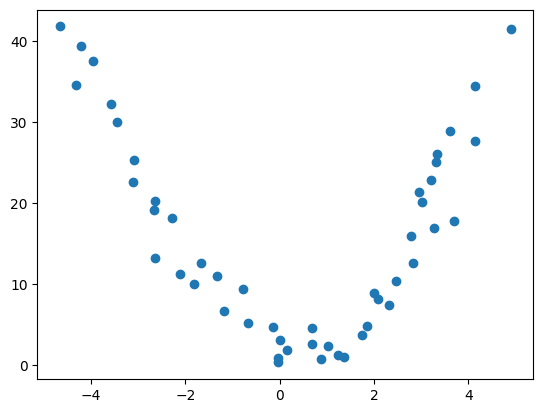

In [6]:
plt.scatter(df["Temperature (°C)"], df["Ice Cream Sales (units)"])

* The relation between feature and target column is very low, so the data is non linear.

In [7]:
X = df[["Temperature (°C)"]]
y = df["Ice Cream Sales (units)"]

In [8]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y, train_size=0.8, random_state=42)

In [9]:
model = LinearRegression()

In [10]:
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_train_pred = model.predict(xtrain)

In [12]:
y_test_pred = model.predict(xtest)

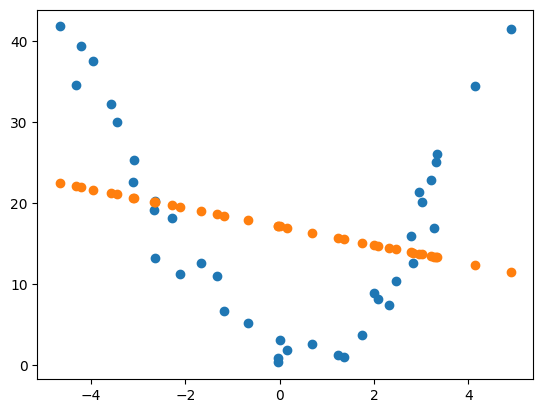

In [13]:
plt.scatter(xtrain, ytrain)
plt.scatter(xtrain, y_train_pred)

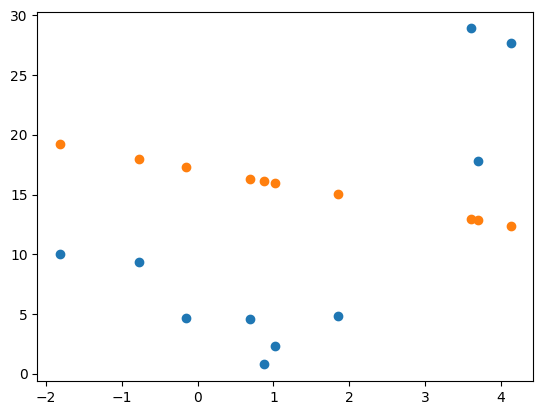

In [14]:
plt.scatter(xtest, ytest)
plt.scatter(xtest, y_test_pred)

In [15]:
r2_train = r2_score(ytrain,y_train_pred)
r2_train

0.06579063815950037

In [16]:
r2_test = r2_score(ytest, y_test_pred)
r2_test

-0.5751270190188227

* The r2 score for train and test data id very low , so the model is underfit
* We can overcome this by applying polynomial regression to this 

In [17]:
poly = PolynomialFeatures(degree=2)
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest = poly.transform(xtest) 

In [18]:
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred_train = model.predict(updated_xtrain)

In [20]:
y_pred_test = model.predict(updated_xtest)

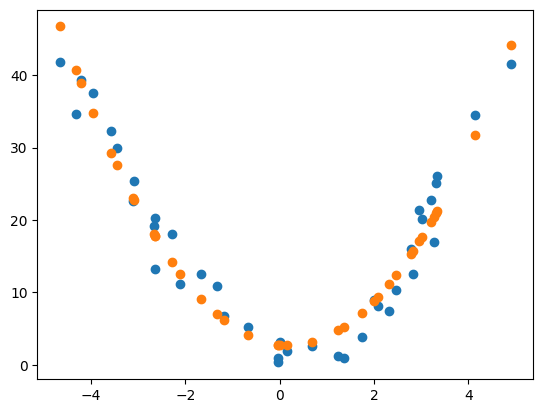

In [21]:
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1], y_pred_train)

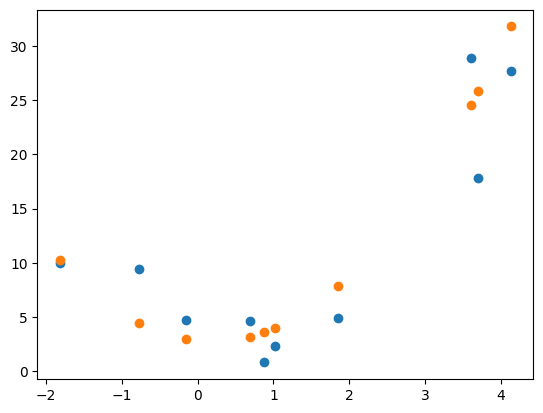

In [22]:
plt.scatter(updated_xtest[:,1],ytest)
plt.scatter(updated_xtest[:,1], y_pred_test)

In [23]:
r2_train_non = r2_score(ytrain,y_pred_train)
r2_train_non

0.9413665676490518

In [24]:
r2_test_non = r2_score(ytest, y_pred_test)
r2_test_non

0.843055137193884

* Both train and test score are good so the model is good fit